# 4.1 概率论基础

> **NOAI竞赛课程 · 模块四：数学基础（第1-2课时）**

---

## 本节目标

概率论是机器学习和人工智能的理论基石。本节将系统学习：

1. 概率的基本概念与公理
2. 条件概率、独立性与贝叶斯定理
3. 常见概率分布
4. 期望与方差
5. Python实战：概率计算与模拟

---

## 一、概率的基本概念

### 1.1 样本空间与事件

- **随机试验**：结果不确定的试验
- **样本空间（Sample Space）** $\Omega$：所有可能结果的集合
- **样本点**：样本空间中的每一个结果
- **事件**：样本空间的子集

**例子**：掷一枚骰子
- 样本空间：$\Omega = \{1, 2, 3, 4, 5, 6\}$
- 事件A = "掷出偶数" = $\{2, 4, 6\}$
- 事件B = "掷出大于4的数" = $\{5, 6\}$

In [34]:
# 事件的集合运算
import numpy as np

omega = set(range(1, 7))
A = {2, 4, 6}  # 掷出偶数
B = {5, 6}     # 掷出大于4的数

print(f"样本空间 Ω = {omega}")
print(f"事件 A（掷出偶数）= {A}")
print(f"事件 B（掷出大于4的数）= {B}")
print(f"A ∪ B（至少满足一个）= {A | B}")
print(f"A ∩ B（同时满足）= {A & B}")

样本空间 Ω = {1, 2, 3, 4, 5, 6}
事件 A（掷出偶数）= {2, 4, 6}
事件 B（掷出大于4的数）= {5, 6}
A ∪ B（至少满足一个）= {2, 4, 5, 6}
A ∩ B（同时满足）= {6}


### 1.2 概率公理（Kolmogorov公理）

概率函数 $P: \mathcal{F} \rightarrow [0, 1]$ 满足以下三条公理：

| 公理 | 内容 |
|------|------|
| **公理1（非负性）** | 对任何事件 $A$，$P(A) \geq 0$ |
| **公理2（规范性）** | $P(\Omega) = 1$ |
| **公理3（可加性）** | 若 $A \cap B = \emptyset$，则 $P(A \cup B) = P(A) + P(B)$ |

### 1.3 概率的加法规则

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

若 $A$ 与 $B$ 互斥（$A \cap B = \emptyset$），则 $P(A \cup B) = P(A) + P(B)$

In [35]:
# 概率的加法规则验证
def prob(event, space):
    return len(event) / len(space)

p_A = prob(A, omega)
p_B = prob(B, omega)
p_AB = prob(A & B, omega)

print(f"P(A) = {p_A:.3f}")
print(f"P(B) = {p_B:.3f}")
print(f"P(A ∩ B) = {p_AB:.3f}")
print(f"P(A ∪ B) = {p_A + p_B - p_AB:.3f}")
print(f"验证: P(A) + P(B) - P(A∩B) = {p_A:.3f} + {p_B:.3f} - {p_AB:.3f} = {p_A + p_B - p_AB:.3f} ✓")

P(A) = 0.500
P(B) = 0.333
P(A ∩ B) = 0.167
P(A ∪ B) = 0.667
验证: P(A) + P(B) - P(A∩B) = 0.500 + 0.333 - 0.167 = 0.667 ✓


### 1.4 概率的乘法规则

$$P(A \cap B) = P(A) \cdot P(B|A) = P(B) \cdot P(A|B)$$

若 $A$ 和 $B$ **相互独立**：$P(A \cap B) = P(A) \cdot P(B)$

In [36]:
# 乘法规则验证
p_AB_direct = prob(A & B, omega)
p_AB_indep = p_A * p_B

print(f"P(A ∩ B) 直接计算 = {p_AB_direct:.3f}")
print(f"P(A) × P(B) = {p_AB_indep:.3f}")
print(f"两者相等，说明 A 与 B 相互独立: {np.isclose(p_AB_direct, p_AB_indep)}")

P(A ∩ B) 直接计算 = 0.167
P(A) × P(B) = 0.167
两者相等，说明 A 与 B 相互独立: True


---

## 二、条件概率与独立性

### 2.1 条件概率

$$P(A|B) = \frac{P(A \cap B)}{P(B)} \quad (P(B) > 0)$$

**例子**：掷骰子，已知掷出偶数，求掷出6的概率：

$$P(\{6\}|B) = \frac{P(\{6\} \cap B)}{P(B)} = \frac{1/6}{3/6} = \frac{1}{3}$$

In [37]:
# 条件概率计算
C = {6}
p_C_given_B = prob(C & B, omega) / prob(B, omega)
print(f"P(掷出6 | 已知为偶数) = {p_C_given_B:.3f}")

P(掷出6 | 已知为偶数) = 0.500


### 2.2 事件的独立性

$$P(A|B) = P(A) \quad \text{或等价地} \quad P(A \cap B) = P(A) \cdot P(B)$$

⚠️ **注意**：独立 ≠ 互斥！

### 2.3 贝叶斯公式推导

由条件概率定义出发，结合两个方向：

$$P(A|B) = \frac{P(A \cap B)}{P(B)} \quad \text{和} \quad P(B|A) = \frac{P(A \cap B)}{P(A)}$$

消去 $P(A \cap B)$，得到 **贝叶斯定理**：

$$\boxed{P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}}$$

其中 $P(B)$ 可由**全概率公式**展开：

$$P(B) = P(B|A) \cdot P(A) + P(B|A^c) \cdot P(A^c)$$

### 2.4 贝叶斯定理的直觉理解

$$\text{后验概率} = \frac{\text{似然} \times \text{先验概率}}{\text{证据}}$$

| 术语 | 符号 | 含义 |
|------|------|------|
| 先验概率 | $P(A)$ | 在看到证据前对A的信念 |
| 似然 | $P(B|A)$ | 在A为真时观察到B的概率 |
| 证据 | $P(B)$ | 观察到的总概率 |
| 后验概率 | $P(A|B)$ | 看到证据后对A的信念 |

**经典案例**：医学检测

某种疾病的患病率为1%，检测准确率99%。

设 $D$ = 患病，$+$ = 检测阳性：
- $P(D) = 0.01$，$P(+|D) = 0.99$，$P(+|D^c) = 0.01$

$$P(D|+) = \frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.01 \times 0.99} = 50\%$$

🎯 **结论**：即使检测准确率高达99%，阳性结果中有一半是误报！

In [38]:
# 贝叶斯定理：医学检测案例
def bayes(prior, likelihood, false_positive):
    p_evidence = likelihood * prior + false_positive * (1 - prior)
    posterior = likelihood * prior / p_evidence
    return posterior, p_evidence

p_disease = 0.01
p_pos_given_d = 0.99
p_pos_given_healthy = 0.01

posterior, evidence = bayes(p_disease, p_pos_given_d, p_pos_given_healthy)

print("=== 贝叶斯定理：医学检测案例 ===")
print(f"\n先验信息:")
print(f"  患病率 P(D) = {p_disease*100:.1f}%")
print(f"  真阳性率 P(+|D) = {p_pos_given_d*100:.1f}%")
print(f"  假阳性率 P(+|D̄) = {p_pos_given_healthy*100:.1f}%")
print(f"\n贝叶斯推理:")
print(f"  P(D|+) = {p_pos_given_d*p_disease:.4f} / {evidence:.4f} = {posterior:.3f}")
print(f"\n✦ 阳性检测结果下，实际患病概率为 {posterior*100:.1f}%")
print(f"✦ 虽然检测准确率99%，但阳性结果中有一半是误报！")
print(f"\n💡 贝叶斯定理：将「先验信念」与「新证据」结合，得到「后验信念」")

=== 贝叶斯定理：医学检测案例 ===

先验信息:
  患病率 P(D) = 1.0%
  真阳性率 P(+|D) = 99.0%
  假阳性率 P(+|D̄) = 1.0%

贝叶斯推理:
  P(D|+) = 0.0099 / 0.0198 = 0.500

✦ 阳性检测结果下，实际患病概率为 50.0%
✦ 虽然检测准确率99%，但阳性结果中有一半是误报！

💡 贝叶斯定理：将「先验信念」与「新证据」结合，得到「后验信念」


---

## 三、贝叶斯定理在机器学习中的应用

### 3.1 朴素贝叶斯分类器

**给定特征 $x_1, x_2, \ldots, x_n$，找到最可能的类别 $y$**：

$$\hat{y} = \arg\max_{y_k} P(y_k | x_1, x_2, \ldots, x_n)$$

由贝叶斯定理展开：

$$\hat{y} = \arg\max_{y_k} P(y_k) \prod_{i=1}^{n} P(x_i | y_k)$$

⚠️ **「朴素」假设**：各特征之间条件独立

In [39]:
# 朴素贝叶斯分类器实现
from collections import defaultdict

data = [
    ('晴天', '热', '弱', '否'), ('晴天', '热', '强', '否'),
    ('阴天', '热', '弱', '是'), ('雨天', '适中', '弱', '是'),
    ('雨天', '冷', '弱', '是'), ('雨天', '冷', '强', '否'),
    ('阴天', '冷', '强', '是'), ('晴天', '适中', '弱', '否'),
    ('晴天', '冷', '弱', '是'), ('雨天', '适中', '弱', '是'),
]

print("=== 朴素贝叶斯分类器：天气与运动 ===")
print("训练数据:")
for row in data:
    print(f"  {row[0]}, {row[1]}, {row[2]} → {row[3]}")

n = len(data)
classes = set(row[3] for row in data)
prior = {}
likelihood = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

for y in classes:
    y_data = [row for row in data if row[3] == y]
    prior[y] = len(y_data) / n
    for fi in range(3):
        for v in set(row[fi] for row in y_data):
            likelihood[y][fi][v] = sum(1 for row in y_data if row[fi] == v) / len(y_data)

test = ('阴天', '冷', '强')
print(f"\n预测: 天气={test[0]}, 温度={test[1]}, 风速={test[2]}")
scores = {}
for y in classes:
    score = prior[y]
    for i, v in enumerate(test):
        score *= likelihood[y][i].get(v, 1e-10)
    scores[y] = score
    print(f"  P({y}) × ∏P(xi|{y}) = {score:.4f}")
print(f"  ➜ 预测结果: {max(scores, key=scores.get)}")

=== 朴素贝叶斯分类器：天气与运动 ===
训练数据:
  晴天, 热, 弱 → 否
  晴天, 热, 强 → 否
  阴天, 热, 弱 → 是
  雨天, 适中, 弱 → 是
  雨天, 冷, 弱 → 是
  雨天, 冷, 强 → 否
  阴天, 冷, 强 → 是
  晴天, 适中, 弱 → 否
  晴天, 冷, 弱 → 是
  雨天, 适中, 弱 → 是

预测: 天气=阴天, 温度=冷, 风速=强
  P(是) × ∏P(xi|是) = 0.0167
  P(否) × ∏P(xi|否) = 0.0000
  ➜ 预测结果: 是


---

## 四、常见概率分布

### 4.1 伯努利分布

$$P(X=k) = \begin{cases} p & k=1 \\ 1-p & k=0 \end{cases}$$

期望：$E[X] = p$，方差：$\text{Var}(X) = p(1-p)$

In [40]:
# 伯努利分布模拟
np.random.seed(42)
p = 0.6
bernoulli = np.random.binomial(1, p, 10000)
print(f"伯努利分布模拟 (p={p}, n=10000):")
print(f"  模拟均值 = {bernoulli.mean():.3f} (理论值: {p:.3f})")
print(f"  模拟方差 = {bernoulli.var():.3f} (理论值: {p*(1-p):.3f})")

伯努利分布模拟 (p=0.6, n=10000):
  模拟均值 = 0.611 (理论值: 0.600)
  模拟方差 = 0.238 (理论值: 0.240)


### 4.2 二项分布

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$

期望：$E[X] = np$，方差：$\text{Var}(X) = np(1-p)$

In [41]:
from scipy.stats import binom
n, p = 10, 0.5
print(f"二项分布 Bin({n},{p}):")
print(f"  P(X=6) = {binom.pmf(6, n, p):.3f}")
print(f"  理论均值 = {n*p:.1f}, 方差 = {n*p*(1-p):.1f}")

二项分布 Bin(10,0.5):
  P(X=6) = 0.205
  理论均值 = 5.0, 方差 = 2.5


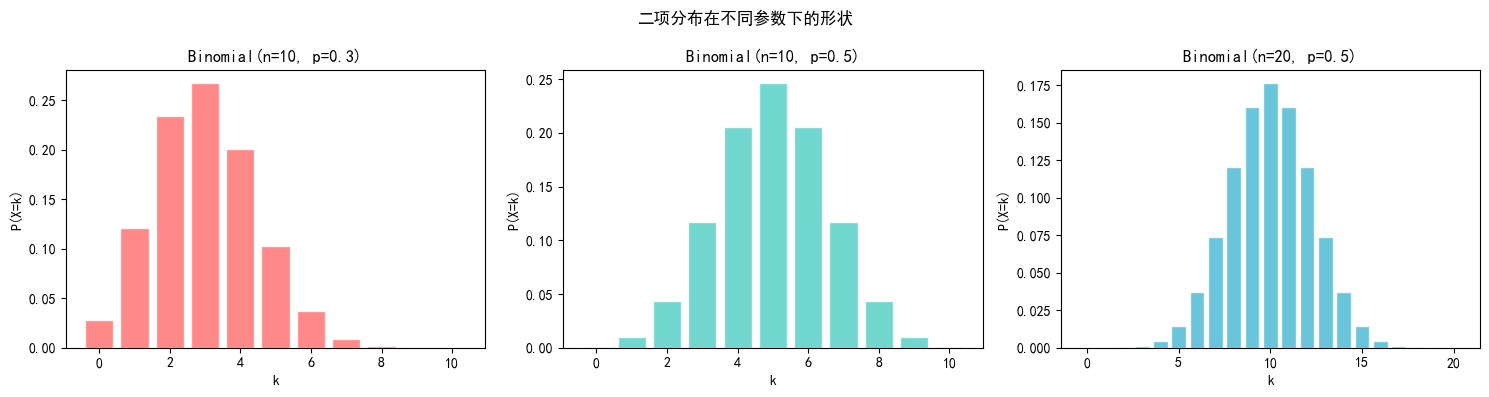

In [42]:
# 可视化二项分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置支持中文的字体
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (n, p), color in zip(axes, [(10,0.3),(10,0.5),(20,0.5)], ['#FF6B6B','#4ECDC4','#45B7D1']):
    k = np.arange(0, n+1)
    ax.bar(k, binom.pmf(k, n, p), color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Binomial(n={n}, p={p})'); ax.set_xlabel('k'); ax.set_ylabel('P(X=k)')
plt.suptitle('二项分布在不同参数下的形状', fontweight='bold'); plt.tight_layout(); plt.show()

### 4.3 正态分布（高斯分布）

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

记作 $X \sim \mathcal{N}(\mu, \sigma^2)$

**$3\sigma$ 法则**：68% / 95% / 99.7% 的数据分别在 $\pm 1\sigma, \pm 2\sigma, \pm 3\sigma$ 内

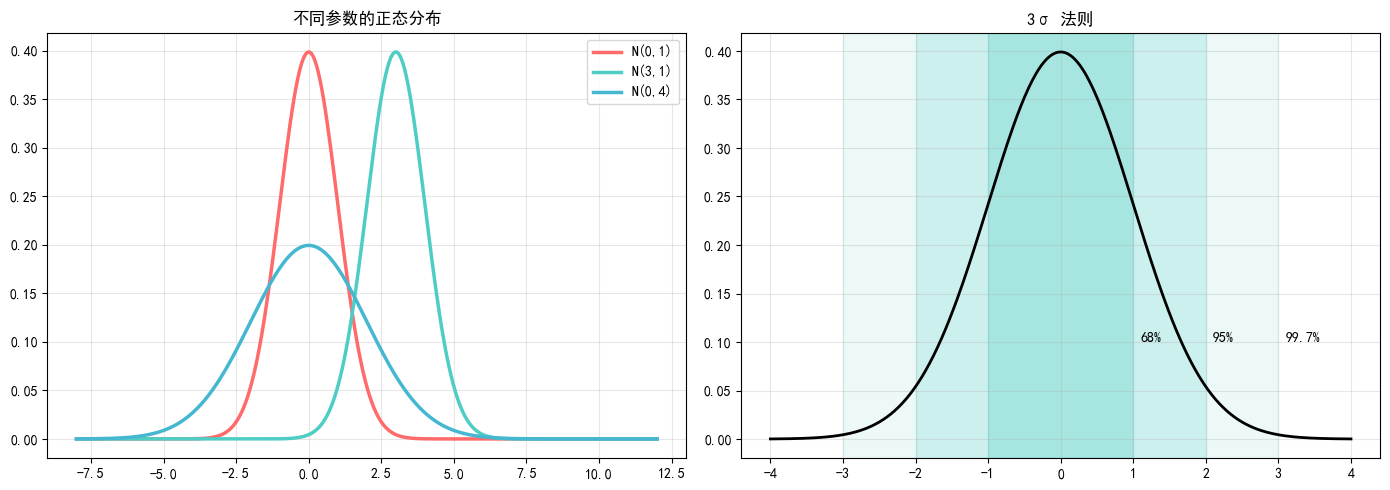

In [43]:
from scipy.stats import norm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.linspace(-8, 12, 300)
for mu, sig, lab, c in [(0,1,'N(0,1)','#FF6B6B'),(3,1,'N(3,1)','#4ECDC4'),(0,2,'N(0,4)','#45B7D1')]:
    axes[0].plot(x, norm.pdf(x, mu, sig), label=lab, color=c, lw=2.5)
axes[0].set_title('不同参数的正态分布', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

mu, sig = 0, 1
x = np.linspace(-4, 4, 300)
axes[1].plot(x, norm.pdf(x), 'k-', lw=2)
for m, a, l in [(1,0.3,'68%'),(2,0.2,'95%'),(3,0.1,'99.7%')]:
    axes[1].axvspan(-m*sig, m*sig, alpha=a, color='#4ECDC4')
    axes[1].text(m*sig+0.1, 0.1, l)
axes[1].set_title('3σ 法则', fontweight='bold'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [44]:
mu, sigma = 100, 15
print(f"N({mu}, {sigma}²) 概率计算:")
print(f"  P(X<85) = {norm.cdf(85, mu, sigma):.3f}")
print(f"  P(85<X<115) = {norm.cdf(115,mu,sigma)-norm.cdf(85,mu,sigma):.3f}")
print(f"  P(X>130) = {1-norm.cdf(130, mu, sigma):.3f}")
print(f"\n模拟验证 (100000次):")
s = np.random.normal(mu, sigma, 100000)
print(f"  样本均值 = {s.mean():.3f}, 标准差 = {s.std():.3f}")

N(100, 15²) 概率计算:
  P(X<85) = 0.159
  P(85<X<115) = 0.683
  P(X>130) = 0.023

模拟验证 (100000次):
  样本均值 = 100.033, 标准差 = 15.002


---

## 五、期望与方差

$$E[X] = \sum_{i} x_i \cdot P(X=x_i), \quad \text{Var}(X) = E[(X-\mu)^2] = \sigma^2$$

| 性质 | 公式 |
|------|------|
| 线性性 | $E[aX+b] = aE[X]+b$ |
| 独立变量和 | $\text{Var}(X+Y) = \text{Var}(X)+\text{Var}(Y)$ |
| 常数乘积 | $\text{Var}(aX) = a^2\text{Var}(X)$ |

In [45]:
np.random.seed(42)
x_vals = np.array([1,2,3,4,5,6])
probs = np.array([0.10,0.15,0.20,0.25,0.20,0.10])

EV = np.sum(x_vals * probs)
Var = np.sum((x_vals - EV)**2 * probs)
print(f"E[X] = {EV:.3f}, Var(X) = {Var:.3f}, Std(X) = {np.sqrt(Var):.3f}")

s = np.random.choice(x_vals, 100000, p=probs)
print(f"\n蒙特卡洛验证: 均值={s.mean():.3f}, 方差={s.var():.3f}")

E[X] = 3.600, Var(X) = 2.140, Std(X) = 1.463

蒙特卡洛验证: 均值=3.597, 方差=2.133


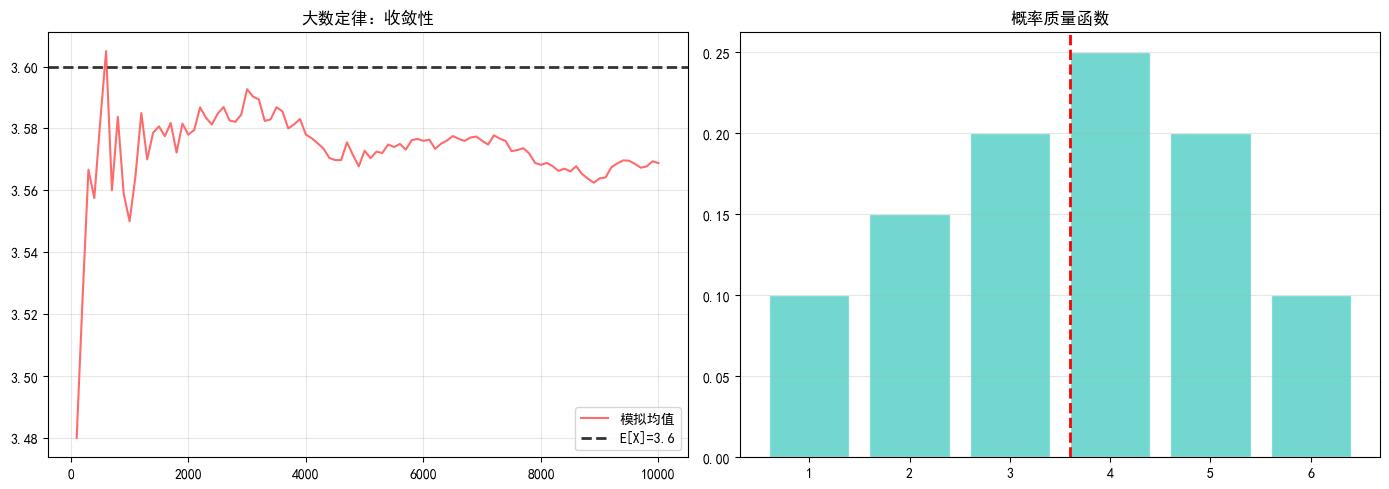

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
np.random.seed(42)
all_s = np.random.choice(x_vals, 10000, p=probs)
ss = np.arange(100, 10001, 100)
axes[0].plot(ss, [all_s[:n].mean() for n in ss], color='#FF6B6B', lw=1.5, label='模拟均值')
axes[0].axhline(EV, color='#333', ls='--', lw=2, label=f'E[X]={EV}')
axes[0].set_title('大数定律：收敛性', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].bar(x_vals, probs, color='#4ECDC4', alpha=0.8, edgecolor='white')
axes[1].axvline(EV, color='red', ls='--', lw=2)
axes[1].set_title('概率质量函数', fontweight='bold'); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

---

## 六、练习题

### 📝 练习1：不放回抽球

袋中有3红5蓝球，抽2个球。求：
1. 两红 2. 先红后蓝 3. 至少一红

In [47]:
np.random.seed(42)
n_r, n_b = 3, 5; t = n_r + n_b
print("=== 练习1：不放回抽球 ===")
p1 = (n_r/t)*((n_r-1)/(t-1))
p2 = (n_r/t)*(n_b/(t-1))
p3 = 1 - (n_b/t)*((n_b-1)/(t-1))
print(f"P(两红) = {p1:.3f}")
print(f"P(先红后蓝) = {p2:.3f}")
print(f"P(至少一红) = {p3:.3f}")

bags = ['R']*n_r + ['B']*n_b
c1=c2=c3=0
for _ in range(100000):
    b1,b2 = np.random.choice(bags, 2, replace=False)
    if b1=='R' and b2=='R': c1+=1
    if b1=='R' and b2=='B': c2+=1
    if 'R' in (b1,b2): c3+=1
print(f"\n蒙特卡洛: {c1/100000:.3f}, {c2/100000:.3f}, {c3/100000:.3f}")

=== 练习1：不放回抽球 ===
P(两红) = 0.107
P(先红后蓝) = 0.268
P(至少一红) = 0.643

蒙特卡洛: 0.107, 0.268, 0.644


### 📝 练习2：贝叶斯应用

工厂A线(60%,次品2%)，B线(40%,次品5%)。次品来自A线的概率？

In [48]:
pA,pB,pdA,pdB = 0.6, 0.4, 0.02, 0.05
pd = pdA*pA + pdB*pB
print(f"P(A|次品) = ({pdA}×{pA}) / {pd:.3f} = {pdA*pA/pd:.3f} ➜ 次品来自A线的概率为 {pdA*pA/pd*100:.1f}%")

P(A|次品) = (0.02×0.6) / 0.032 = 0.375 ➜ 次品来自A线的概率为 37.5%


### 📝 练习3：正态分布

NOAI分数 ~ N(72, 64)。求：P(X>85), 100人中>90分的人数, 前10%分数线。

In [49]:
mu,sig = 72, 8
print(f"1. P(>85) = {1-norm.cdf(85,mu,sig):.3f}")
print(f"2. P(>90) = {1-norm.cdf(90,mu,sig):.3f} → 约{int(round(100*(1-norm.cdf(90,mu,sig))))}人")
print(f"3. 前10%线 = {norm.ppf(0.9, mu, sig):.1f}分")

1. P(>85) = 0.052
2. P(>90) = 0.012 → 约1人
3. 前10%线 = 82.3分


---

## 📌 本节要点

1. 概率公理、加法/乘法规则是基础
2. 条件概率 $P(A|B)$ 和贝叶斯定理 $P(A|B)=\frac{P(B|A)P(A)}{P(B)}$
3. 朴素贝叶斯：特征独立假设下的分类器
4. 三大分布：伯努利 → 二项 → 正态
5. 期望与方差衡量分布的中心和离散程度

🚀 **下一节**：[4.2 统计学基础](./4.2_统计学基础.ipynb)